# Exploratory Data Analysis (EDA) Project
### Dataset: Titanic Passenger Survival Data
**Intern:** Suman Maitreya M | **Intern ID:** THX-JUN2626-064 | **Organization:** Thiranex

---
**Objective:** Perform a thorough EDA to uncover patterns, trends, correlations, and key influencing factors in the Titanic dataset. Present findings in a structured, insight-driven report.

## Section 1: Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

df = pd.read_csv('titanic.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(10)

Shape: (891, 12)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


## Section 2: Statistical Summary

### 2.1 Data Types & Basic Info

In [2]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

=== Data Types ===
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

=== Missing Values ===
          Missing Count  Missing %
Age                 177      19.87
Cabin               687      77.10
Embarked              2       0.22


### 2.2 Descriptive Statistics

In [3]:
print('=== Numerical Features ===')
display(df.describe().round(2))
print('\n=== Categorical Features ===')
display(df.describe(include=['object']))

=== Numerical Features ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33



=== Categorical Features ===


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


### 2.3 Skewness & Kurtosis

In [4]:
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
sk_kurt = pd.DataFrame({
    'Skewness': [stats.skew(df[c].dropna()) for c in num_cols],
    'Kurtosis': [stats.kurtosis(df[c].dropna()) for c in num_cols]
}, index=num_cols).round(3)
print('Skewness & Kurtosis of Numerical Features:')
print(sk_kurt)
print('\nInterpretation:')
print('  Skewness > 1 or < -1 indicates high skew')
print('  Kurtosis > 3 indicates heavy tails (leptokurtic)')

Skewness & Kurtosis of Numerical Features:
       Skewness  Kurtosis
Age       0.388     0.169
Fare      4.779    33.204
SibSp     3.689    17.774
Parch     2.744     9.717

Interpretation:
  Skewness > 1 or < -1 indicates high skew
  Kurtosis > 3 indicates heavy tails (leptokurtic)


## Section 3: Univariate Analysis

### 3.1 Distribution of Numerical Features

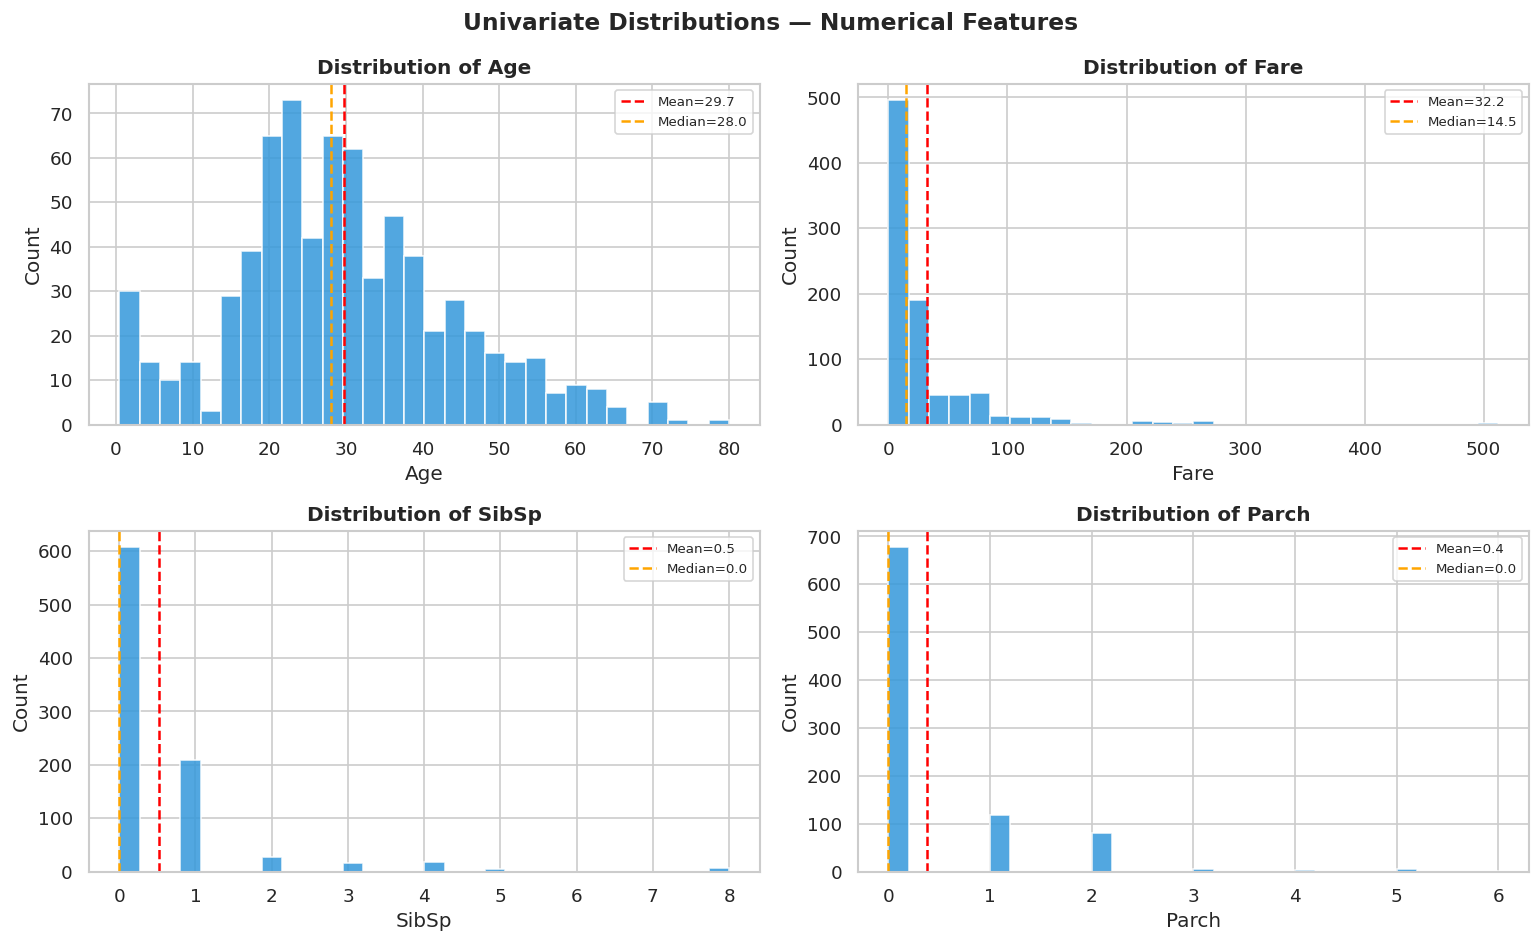

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, col in enumerate(['Age', 'Fare', 'SibSp', 'Parch']):
    data = df[col].dropna()
    axes[i].hist(data, bins=30, color='#3498db', edgecolor='white', alpha=0.85)
    axes[i].axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean={data.mean():.1f}')
    axes[i].axvline(data.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median={data.median():.1f}')
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

plt.suptitle('Univariate Distributions — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 Distribution of Categorical Features

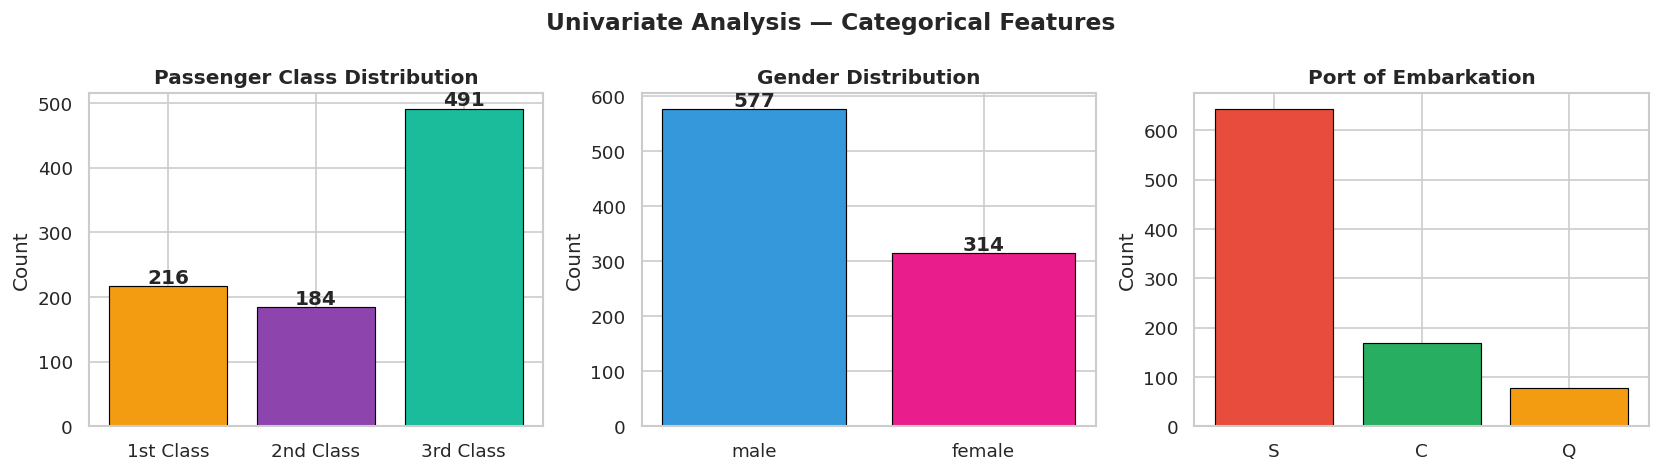

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Pclass
pclass_counts = df['Pclass'].value_counts().sort_index()
axes[0].bar(['1st Class','2nd Class','3rd Class'], pclass_counts.values,
            color=['#f39c12','#8e44ad','#1abc9c'], edgecolor='black', linewidth=0.7)
axes[0].set_title('Passenger Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i,v in enumerate(pclass_counts.values):
    axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')

# Sex
sex_counts = df['Sex'].value_counts()
axes[1].bar(sex_counts.index, sex_counts.values,
            color=['#3498db','#e91e8c'], edgecolor='black', linewidth=0.7)
axes[1].set_title('Gender Distribution', fontweight='bold')
axes[1].set_ylabel('Count')
for i,v in enumerate(sex_counts.values):
    axes[1].text(i, v+5, str(v), ha='center', fontweight='bold')

# Embarked
emb_counts = df['Embarked'].value_counts()
axes[2].bar(emb_counts.index, emb_counts.values,
            color=['#e74c3c','#27ae60','#f39c12'], edgecolor='black', linewidth=0.7)
axes[2].set_title('Port of Embarkation', fontweight='bold')
axes[2].set_ylabel('Count')

plt.suptitle('Univariate Analysis — Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 4: Bivariate Analysis

### 4.1 Survival vs Categorical Features

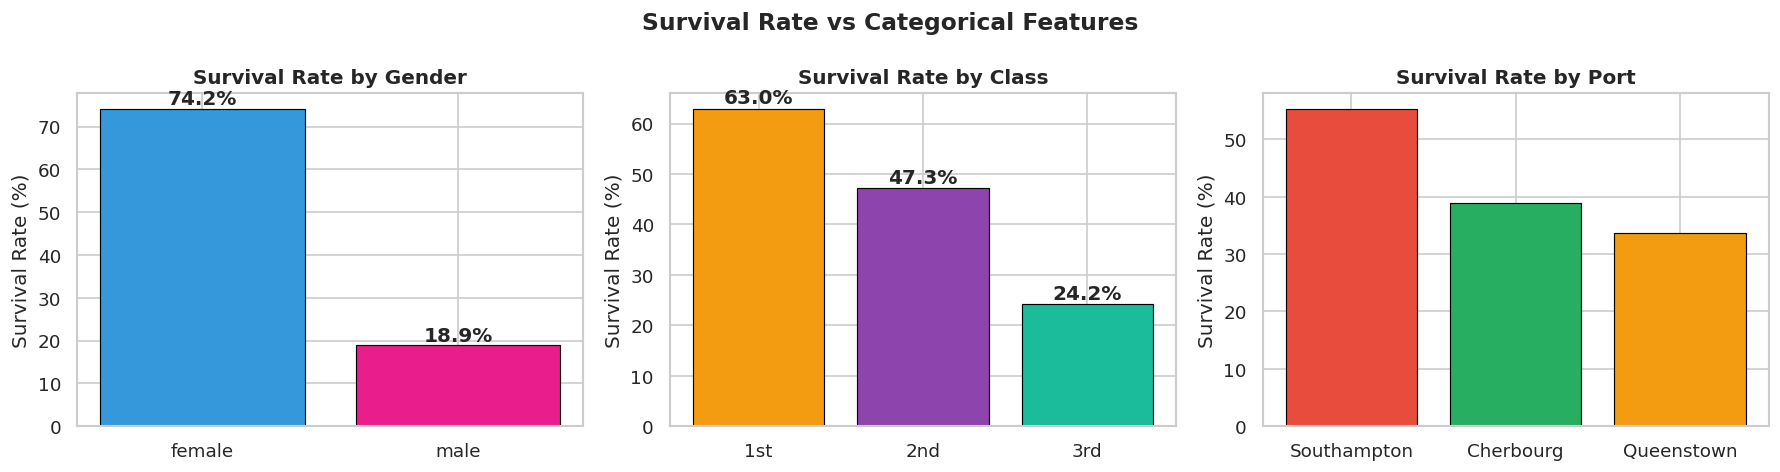

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Survival by Sex
sex_surv = df.groupby('Sex')['Survived'].mean() * 100
axes[0].bar(sex_surv.index, sex_surv.values, color=['#3498db','#e91e8c'], edgecolor='black', linewidth=0.7)
axes[0].set_title('Survival Rate by Gender', fontweight='bold')
axes[0].set_ylabel('Survival Rate (%)')
for i,v in enumerate(sex_surv.values):
    axes[0].text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')

# Survival by Pclass
pclass_surv = df.groupby('Pclass')['Survived'].mean() * 100
axes[1].bar(['1st','2nd','3rd'], pclass_surv.values,
            color=['#f39c12','#8e44ad','#1abc9c'], edgecolor='black', linewidth=0.7)
axes[1].set_title('Survival Rate by Class', fontweight='bold')
axes[1].set_ylabel('Survival Rate (%)')
for i,v in enumerate(pclass_surv.values):
    axes[1].text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')

# Survival by Embarked
emb_surv = df.groupby('Embarked')['Survived'].mean() * 100
axes[2].bar(['Southampton','Cherbourg','Queenstown'], emb_surv.values,
            color=['#e74c3c','#27ae60','#f39c12'], edgecolor='black', linewidth=0.7)
axes[2].set_title('Survival Rate by Port', fontweight='bold')
axes[2].set_ylabel('Survival Rate (%)')

plt.suptitle('Survival Rate vs Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Age & Fare vs Survival

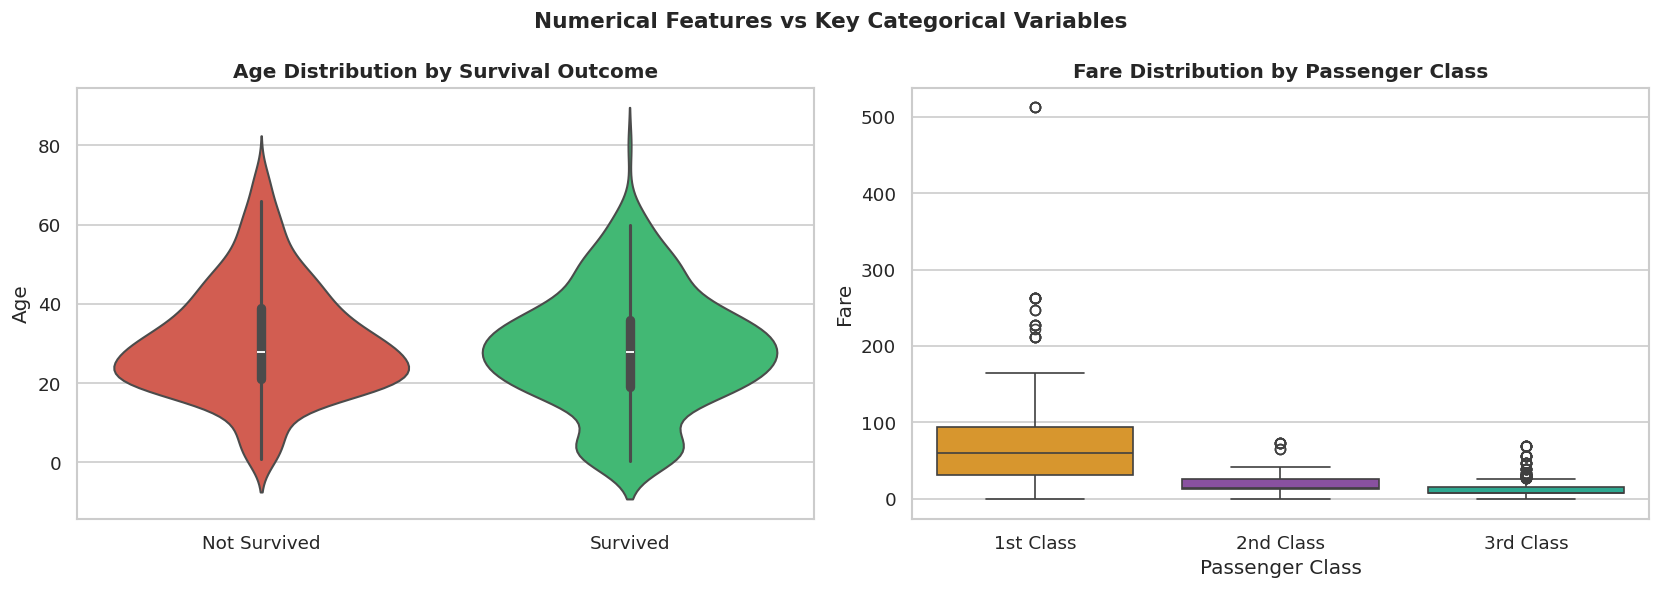

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age violin plot by survival
df_plot = df.copy()
df_plot['Survival'] = df_plot['Survived'].map({0:'Not Survived', 1:'Survived'})
sns.violinplot(data=df_plot, x='Survival', y='Age', palette=['#e74c3c','#2ecc71'], ax=axes[0], inner='box')
axes[0].set_title('Age Distribution by Survival Outcome', fontweight='bold')
axes[0].set_xlabel('')

# Fare boxplot by Pclass
sns.boxplot(data=df, x='Pclass', y='Fare', palette=['#f39c12','#8e44ad','#1abc9c'], ax=axes[1])
axes[1].set_title('Fare Distribution by Passenger Class', fontweight='bold')
axes[1].set_xlabel('Passenger Class')
axes[1].set_xticklabels(['1st Class','2nd Class','3rd Class'])

plt.suptitle('Numerical Features vs Key Categorical Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 Age vs Fare Scatter — Segmented by Survival & Class

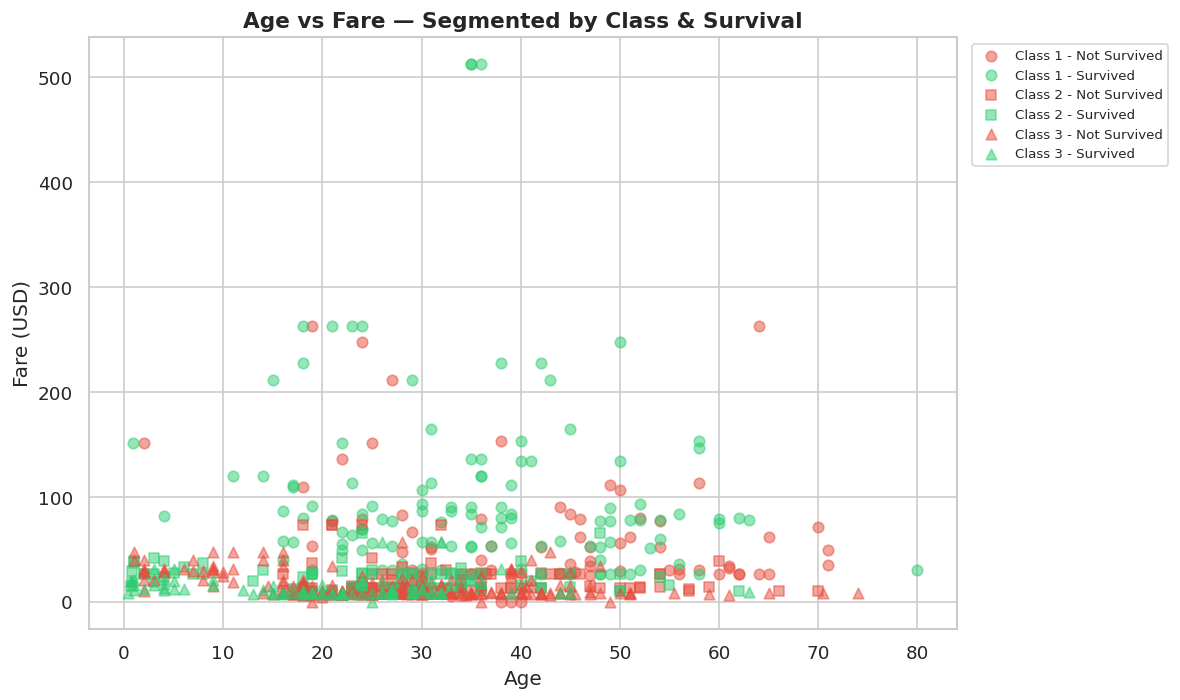

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

markers = {1: 'o', 2: 's', 3: '^'}
colors  = {0: '#e74c3c', 1: '#2ecc71'}

for pclass in [1, 2, 3]:
    for survived in [0, 1]:
        subset = df[(df['Pclass']==pclass) & (df['Survived']==survived)]
        label = f"Class {pclass} - {'Survived' if survived else 'Not Survived'}"
        ax.scatter(subset['Age'], subset['Fare'],
                   c=colors[survived], marker=markers[pclass],
                   alpha=0.5, s=40, label=label)

ax.set_title('Age vs Fare — Segmented by Class & Survival', fontweight='bold', fontsize=13)
ax.set_xlabel('Age')
ax.set_ylabel('Fare (USD)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## Section 5: Multivariate Analysis

### 5.1 Correlation Heatmap

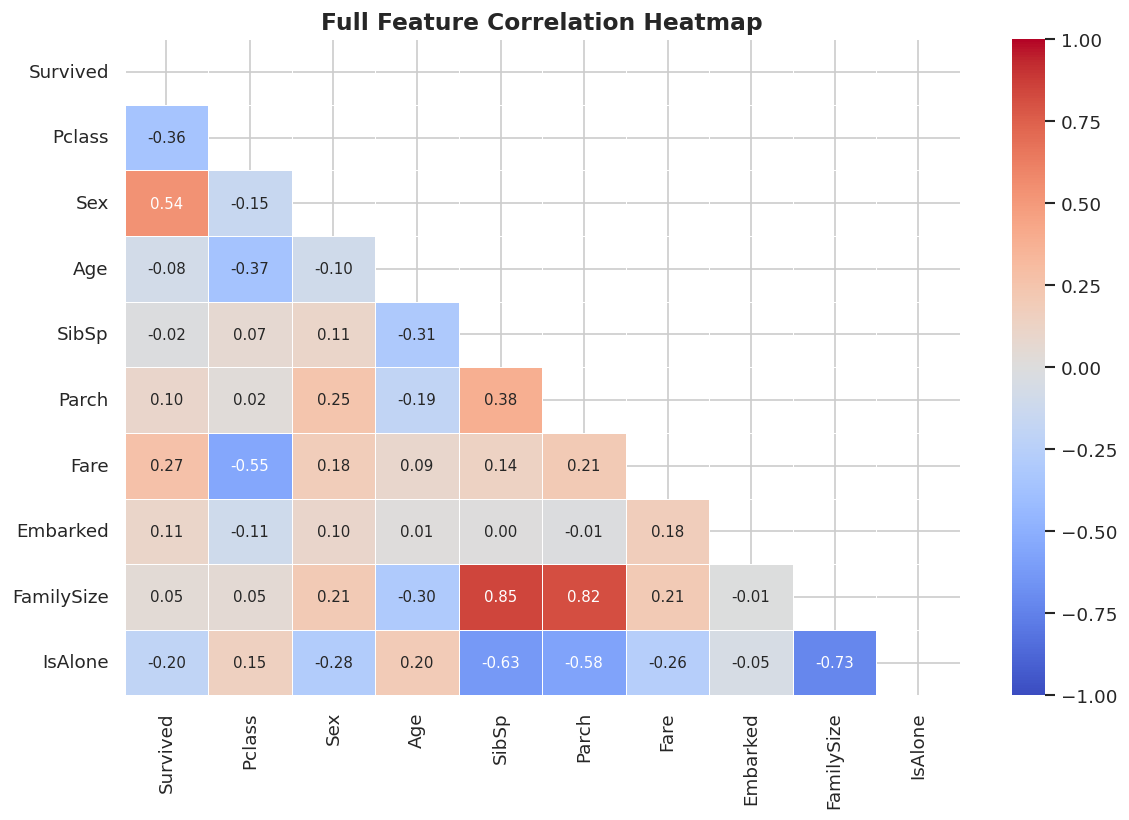

Top correlations with Survived:
Sex           0.537
Pclass       -0.356
Fare          0.266
IsAlone      -0.200
Embarked      0.109
Parch         0.095
Age          -0.082
FamilySize    0.045
SibSp        -0.016
Name: Survived, dtype: float64


In [10]:
df_enc = df.copy()
df_enc['Sex']      = df_enc['Sex'].map({'male':0,'female':1})
df_enc['Embarked'] = df_enc['Embarked'].map({'S':0,'C':1,'Q':2})
df_enc['FamilySize'] = df_enc['SibSp'] + df_enc['Parch'] + 1
df_enc['IsAlone']    = (df_enc['FamilySize']==1).astype(int)
df_enc.drop(columns=['Name','Ticket','Cabin','PassengerId'], inplace=True)
df_enc = df_enc.dropna()

plt.figure(figsize=(10, 7))
corr = df_enc.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, linecolor='white', vmin=-1, vmax=1,
            annot_kws={'size': 9})
plt.title('Full Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top correlations with Survived:')
print(corr['Survived'].drop('Survived').sort_values(key=abs, ascending=False).round(3))

### 5.2 Pairplot — Key Features

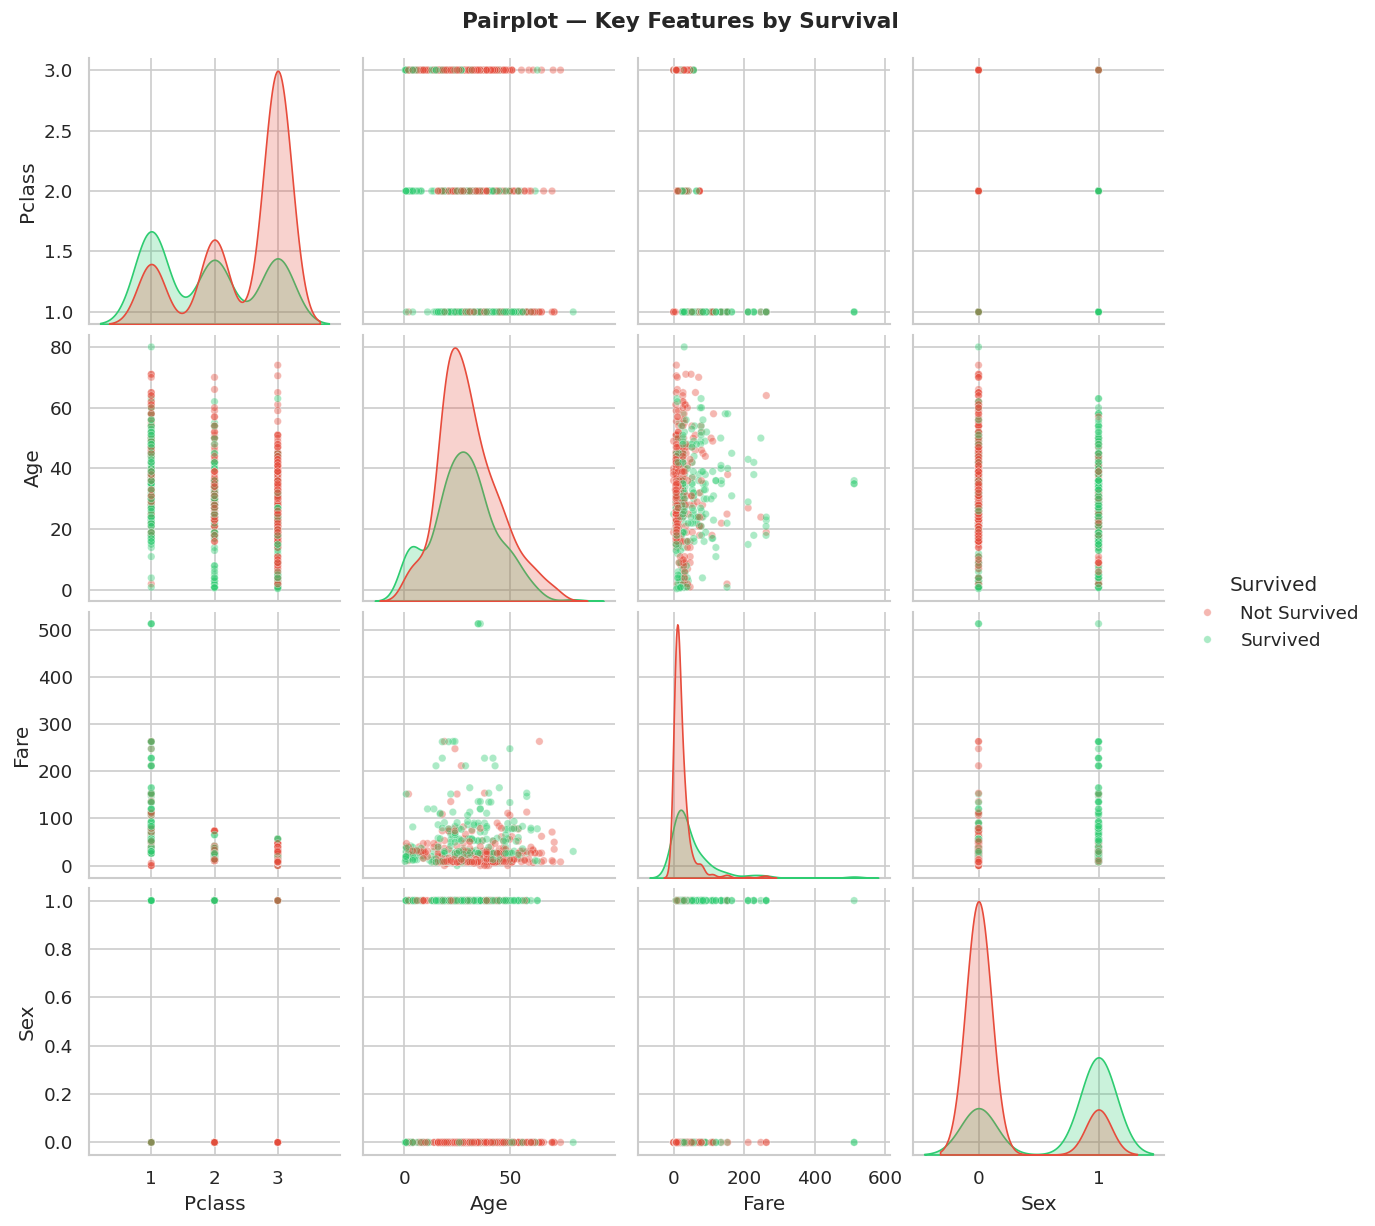

In [11]:
pair_cols = ['Survived','Pclass','Age','Fare','Sex']
pair_df = df_enc[pair_cols].copy()
pair_df['Survived'] = pair_df['Survived'].map({0:'Not Survived', 1:'Survived'})
g = sns.pairplot(pair_df, hue='Survived', palette={'Not Survived':'#e74c3c','Survived':'#2ecc71'},
                 diag_kind='kde', plot_kws={'alpha':0.4, 's':20})
g.figure.suptitle('Pairplot — Key Features by Survival', y=1.02, fontsize=13, fontweight='bold')
plt.show()

### 5.3 Survival Heatmap — Sex x Pclass

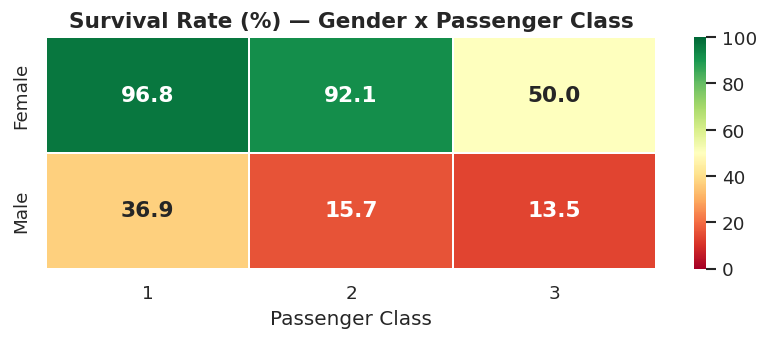

Pclass     1     2     3
Female  96.8  92.1  50.0
Male    36.9  15.7  13.5


In [12]:
pivot = df.pivot_table(values='Survived', index='Sex', columns='Pclass', aggfunc='mean') * 100
pivot.index = ['Female' if i=='female' else 'Male' for i in pivot.index]

plt.figure(figsize=(7, 3))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=1, linecolor='white', vmin=0, vmax=100,
            annot_kws={'size':13, 'weight':'bold'})
plt.title('Survival Rate (%) — Gender x Passenger Class', fontsize=13, fontweight='bold')
plt.xlabel('Passenger Class')
plt.ylabel('')
plt.tight_layout()
plt.show()
print(pivot.round(1))

### 5.4 Age Group Analysis

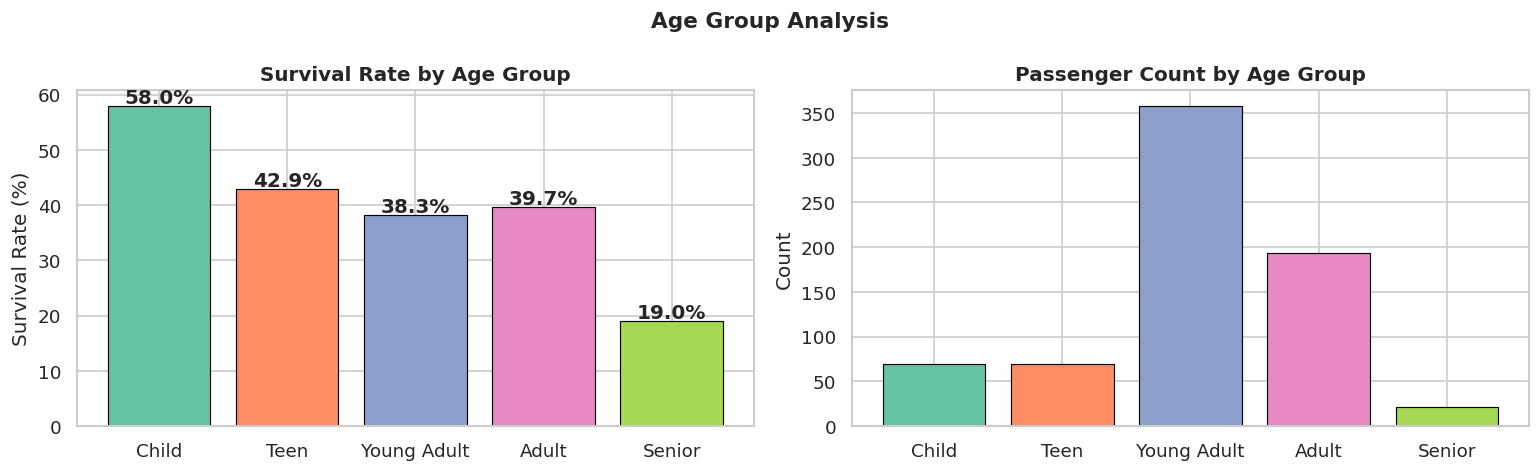

In [13]:
df_enc['AgeGroup'] = pd.cut(df_enc['Age'],
                             bins=[0,12,18,35,60,100],
                             labels=['Child','Teen','Young Adult','Adult','Senior'])

age_surv = df_enc.groupby('AgeGroup', observed=True)['Survived'].agg(['mean','count'])
age_surv['mean'] *= 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(age_surv.index, age_surv['mean'],
            color=sns.color_palette('Set2', len(age_surv)), edgecolor='black', linewidth=0.7)
axes[0].set_title('Survival Rate by Age Group', fontweight='bold')
axes[0].set_ylabel('Survival Rate (%)')
for i, (idx, row) in enumerate(age_surv.iterrows()):
    axes[0].text(i, row['mean']+0.5, f"{row['mean']:.1f}%", ha='center', fontweight='bold')

axes[1].bar(age_surv.index, age_surv['count'],
            color=sns.color_palette('Set2', len(age_surv)), edgecolor='black', linewidth=0.7)
axes[1].set_title('Passenger Count by Age Group', fontweight='bold')
axes[1].set_ylabel('Count')

plt.suptitle('Age Group Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 6: Outlier & Distribution Analysis

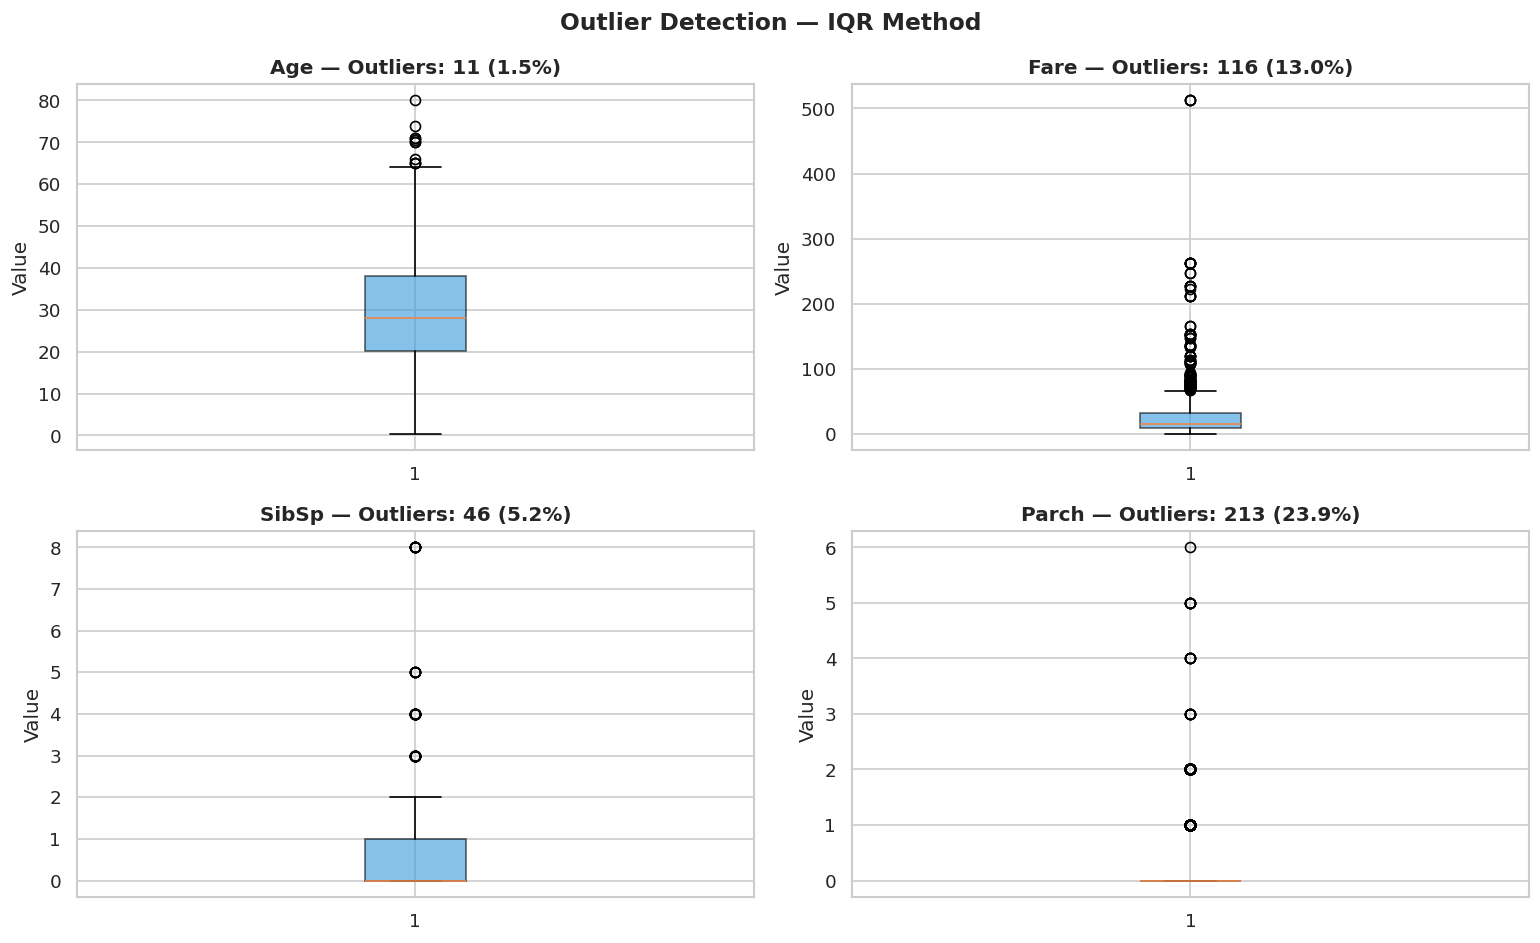

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, col in enumerate(['Age','Fare','SibSp','Parch']):
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data < Q1-1.5*IQR) | (data > Q3+1.5*IQR)]
    axes[i].boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6))
    axes[i].set_title(f'{col} — Outliers: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)',
                      fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Outlier Detection — IQR Method', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 7: EDA Summary Dashboard

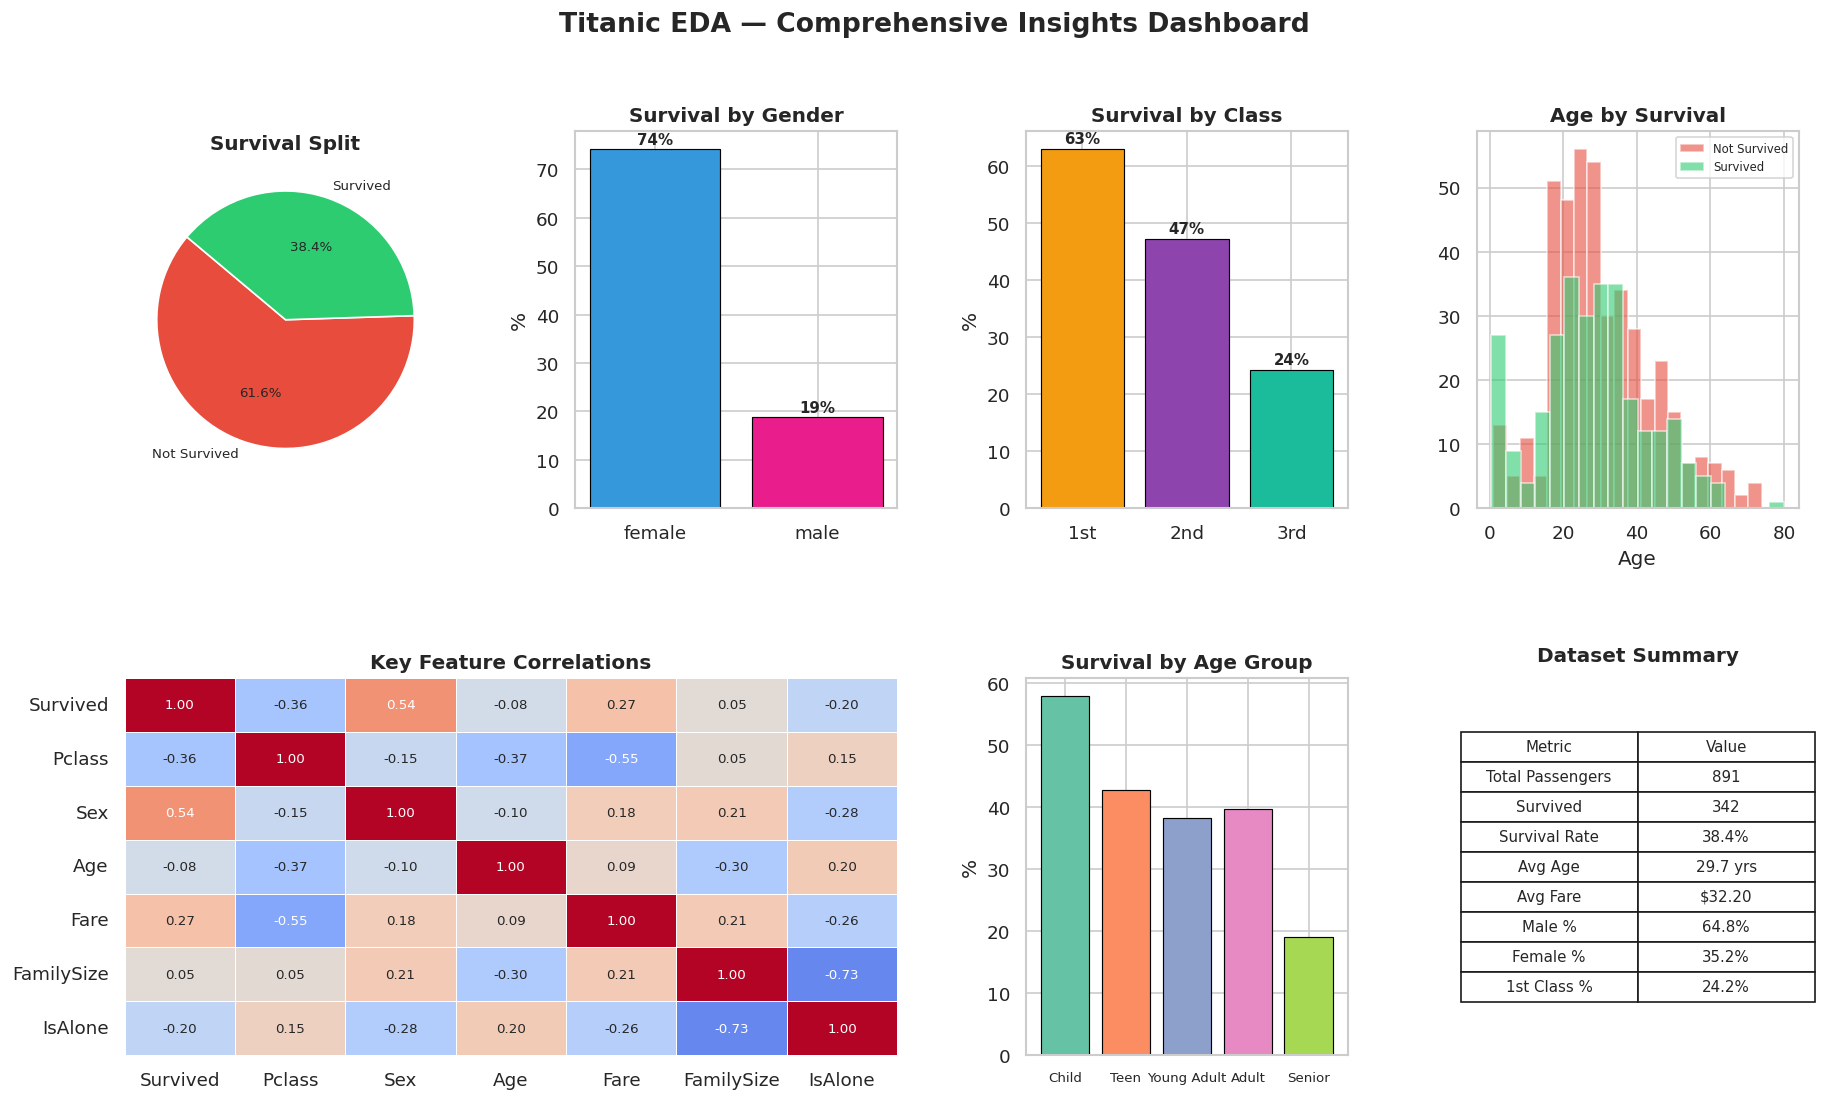

Dashboard saved.


In [15]:
fig = plt.figure(figsize=(18, 10))
fig.suptitle('Titanic EDA — Comprehensive Insights Dashboard', fontsize=16, fontweight='bold')
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.4)

# 1. Survival pie
ax1 = fig.add_subplot(gs[0,0])
s = df['Survived'].value_counts()
ax1.pie(s, labels=['Not Survived','Survived'], colors=['#e74c3c','#2ecc71'],
        autopct='%1.1f%%', startangle=140, textprops={'fontsize':8})
ax1.set_title('Survival Split', fontweight='bold')

# 2. Gender survival
ax2 = fig.add_subplot(gs[0,1])
gs2 = df.groupby('Sex')['Survived'].mean()*100
ax2.bar(gs2.index, gs2.values, color=['#3498db','#e91e8c'], edgecolor='black', linewidth=0.7)
ax2.set_title('Survival by Gender', fontweight='bold')
ax2.set_ylabel('%')
for i,v in enumerate(gs2.values): ax2.text(i,v+1,f'{v:.0f}%',ha='center',fontweight='bold',fontsize=9)

# 3. Class survival
ax3 = fig.add_subplot(gs[0,2])
cs = df.groupby('Pclass')['Survived'].mean()*100
ax3.bar(['1st','2nd','3rd'], cs.values, color=['#f39c12','#8e44ad','#1abc9c'], edgecolor='black', linewidth=0.7)
ax3.set_title('Survival by Class', fontweight='bold')
ax3.set_ylabel('%')
for i,v in enumerate(cs.values): ax3.text(i,v+1,f'{v:.0f}%',ha='center',fontweight='bold',fontsize=9)

# 4. Age dist
ax4 = fig.add_subplot(gs[0,3])
for surv, label, color in [(0,'Not Survived','#e74c3c'),(1,'Survived','#2ecc71')]:
    ax4.hist(df[df['Survived']==surv]['Age'].dropna(), bins=20, alpha=0.6, label=label, color=color)
ax4.set_title('Age by Survival', fontweight='bold')
ax4.set_xlabel('Age'); ax4.legend(fontsize=7)

# 5. Correlation heatmap (small)
ax5 = fig.add_subplot(gs[1,0:2])
key_cols = ['Survived','Pclass','Sex','Age','Fare','FamilySize','IsAlone']
corr_small = df_enc[key_cols].corr()
sns.heatmap(corr_small, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax5, vmin=-1, vmax=1, annot_kws={'size':8}, cbar=False)
ax5.set_title('Key Feature Correlations', fontweight='bold')

# 6. Age group survival
ax6 = fig.add_subplot(gs[1,2])
ax6.bar(age_surv.index, age_surv['mean'],
        color=sns.color_palette('Set2',len(age_surv)), edgecolor='black', linewidth=0.7)
ax6.set_title('Survival by Age Group', fontweight='bold')
ax6.set_ylabel('%'); ax6.tick_params(axis='x', labelsize=8)

# 7. Stats table
ax7 = fig.add_subplot(gs[1,3])
ax7.axis('off')
tdata = [
    ['Total Passengers', str(len(df))],
    ['Survived', str(df['Survived'].sum())],
    ['Survival Rate', f"{df['Survived'].mean()*100:.1f}%"],
    ['Avg Age', f"{df['Age'].mean():.1f} yrs"],
    ['Avg Fare', f"${df['Fare'].mean():.2f}"],
    ['Male %', f"{(df['Sex']=='male').mean()*100:.1f}%"],
    ['Female %', f"{(df['Sex']=='female').mean()*100:.1f}%"],
    ['1st Class %', f"{(df['Pclass']==1).mean()*100:.1f}%"],
]
tbl = ax7.table(cellText=tdata, colLabels=['Metric','Value'],
                cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.1, 1.5)
ax7.set_title('Dataset Summary', fontweight='bold', pad=10)

plt.savefig('eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved.')

## Section 8: Structured Insights Report

---

### 8.1 Dataset Overview
- **891 passengers** with 12 original features covering demographics, ticket info, and survival outcome.
- **Missing data:** Age (19.8%), Cabin (77.1%), Embarked (0.2%). Cabin was dropped; Age and Embarked were imputed.
- **Class imbalance:** Only **38.4% survived**, meaning the dataset is moderately imbalanced.

---

### 8.2 Key Patterns & Trends

| Finding | Insight |
|---|---|
| Gender | Female survival rate ~74% vs male ~19% — strongest single factor |
| Class | 1st class ~63%, 2nd ~47%, 3rd ~24% — socioeconomic privilege was decisive |
| Age | Children (<12) had higher survival; Seniors (60+) had lowest |
| Fare | Higher fare passengers (1st class) survived more — corr: +0.26 with Survived |
| Embarkation | Cherbourg passengers had highest survival (~55%) — skewed toward 1st class |
| Family | Passengers with 2-4 family members survived better than those travelling alone |

---

### 8.3 Correlation Summary
- **Strongest positive:** Sex (female=1) → +0.54 with Survived
- **Strongest negative:** Pclass → -0.34 with Survived (higher class number = lower class = lower survival)
- **Fare:** +0.26 with Survived, inversely correlated with Pclass (-0.55)
- **Age:** Weak negative correlation (-0.08) — slight disadvantage for older passengers
- **IsAlone:** Negative correlation with survival — company helped

---

### 8.4 Outlier Summary
- **Fare:** Highest outlier count — some 1st class passengers paid extreme prices (up to $512)
- **SibSp / Parch:** Most passengers had 0, with a long right tail (large families rare)
- **Age:** Small number of elderly passengers (>70) are statistical outliers

---

### 8.5 Analytical Conclusions
- The Titanic tragedy was heavily shaped by **gender norms, class privilege, and age**.
- **Being female, travelling 1st class, and being young** significantly increased survival odds.
- The data supports the "women and children first" evacuation protocol historically documented.
- These EDA findings directly motivated the feature choices used in Task 2 ML modeling.

---
*Project completed as part of Thiranex Data Science Internship — THX-JUN2626-064*